# Imports and Paths

In [3]:
import glob
import os 
import xarray as xr
import pandas as pd
import numpy as np
import datetime as dt
from shared_plotting import *
import dask.distributed as dd
import matplotlib.dates as mdates
from shared_model_params import alt

In [4]:
runs = ['lc1960','lc2019']

# Preprocess tobac output

We first need to combine the files from tobac output. The way I have the scripts set up so far, I end up with one parquet that has all identified clouds + tracks ("/combined_cond-w-pcp_segmented_tracks.pq"), where a cloud means condensate + updraft (+ potentially with precipitation associated). But these still need to be combined with the calculated statistics for each field.

In [116]:
run = runs[1]

tobacPath = f'/squall/gleung/borneolcc-analysis/tobac/{run}_rte'

In [117]:
tracks = pd.read_parquet(f"{tobacPath}/combined_cond-w-pcp_segmented_tracks.pq")

In [118]:
cloud = pd.DataFrame()

for i in sorted(glob.glob(f"{tobacPath}/cloud_statistics_*.pq")):
    print(i)
    temp = pd.read_parquet(i)

    if len(cloud)==0:
        cloud = temp.copy()
    else:
        new_times = temp.time.unique()
        old_times = cloud.time.unique()

        if len(np.intersect1d(new_times,old_times))==0:
            cloud = pd.concat([cloud, temp]).sort_values('time')
        else:
            cloud = cloud[~cloud.time.isin(np.intersect1d(new_times,old_times))]

            cloud = pd.concat([cloud,temp]).sort_values('time')
    # Where the times overlap, should use the more recent one (which I think is only the last pq file made in December vs. the first one made in January)


/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_00.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_01.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_02.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_03.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_04.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_05.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_06.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_07.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_08.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_09.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_10.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_11.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/cloud_statistics_12.pq
/squall/gleung/borneolcc-analysis/toba

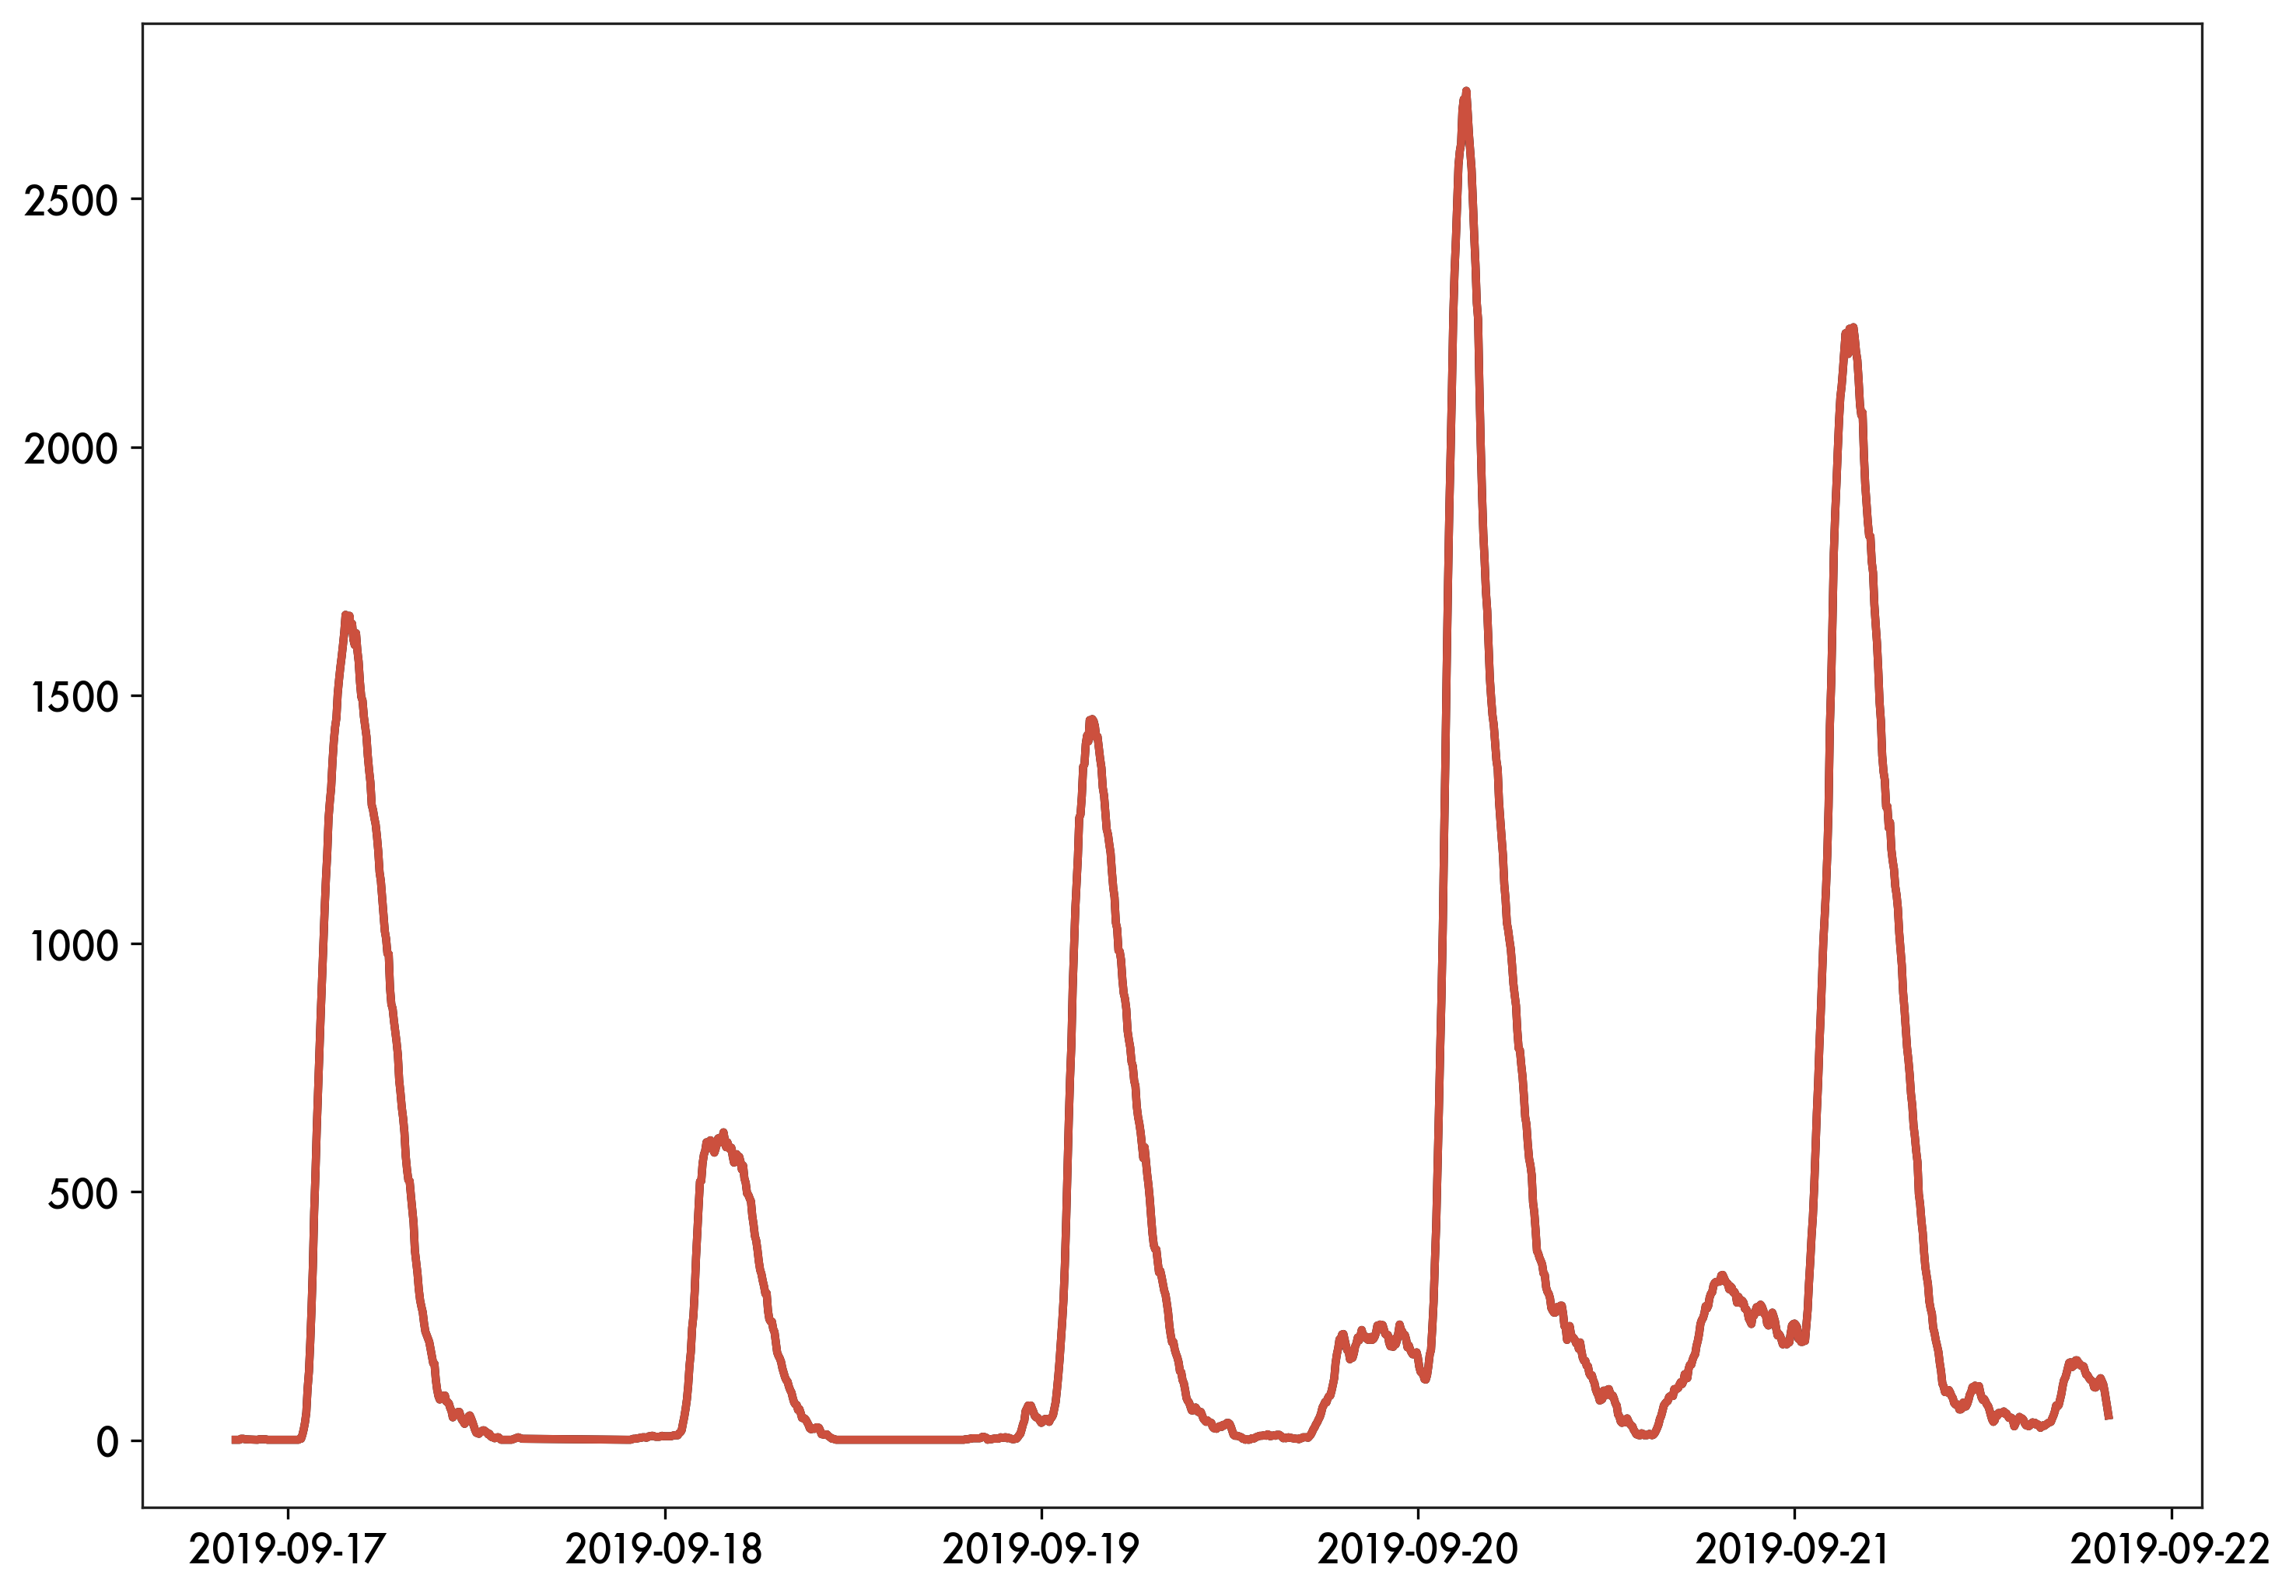

In [120]:
plt.plot(tracks.groupby('time').cell.count(),color='black')
plt.plot(cloud.groupby('time').cell.count(),color=red)

In [119]:
cloud = cloud.set_index(['time','hdim_1','hdim_2','vdim'])
tracks = tracks.set_index(['time','hdim_1','hdim_2','vdim'])

for var in ['CTH','CBH','condensate_volume','condensate_count']:
    tracks[var] = tracks.index.map(cloud[var])

In [121]:
pcp = pd.DataFrame()

for i in sorted(glob.glob(f"{tobacPath}/pcp_statistics_*.pq")):
    print(i)
    temp = pd.read_parquet(i)

    if len(pcp)==0:
        pcp = temp.copy()
    else:
        new_times = temp.time.unique()
        old_times = pcp.time.unique()

        if len(np.intersect1d(new_times,old_times))==0:
            pcp = pd.concat([pcp, temp]).sort_values('time')
        else:
            pcp = pcp[~pcp.time.isin(np.intersect1d(new_times,old_times))]

            pcp = pd.concat([pcp,temp]).sort_values('time')
    # Where the times overlap, should use the more recent one (which I think is only the last pq file made in December vs. the first one made in January)


/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_00.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_01.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_02.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_03.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_04.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_05.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_06.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_07.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_08.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_09.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_10.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_11.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistics_12.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/pcp_statistic

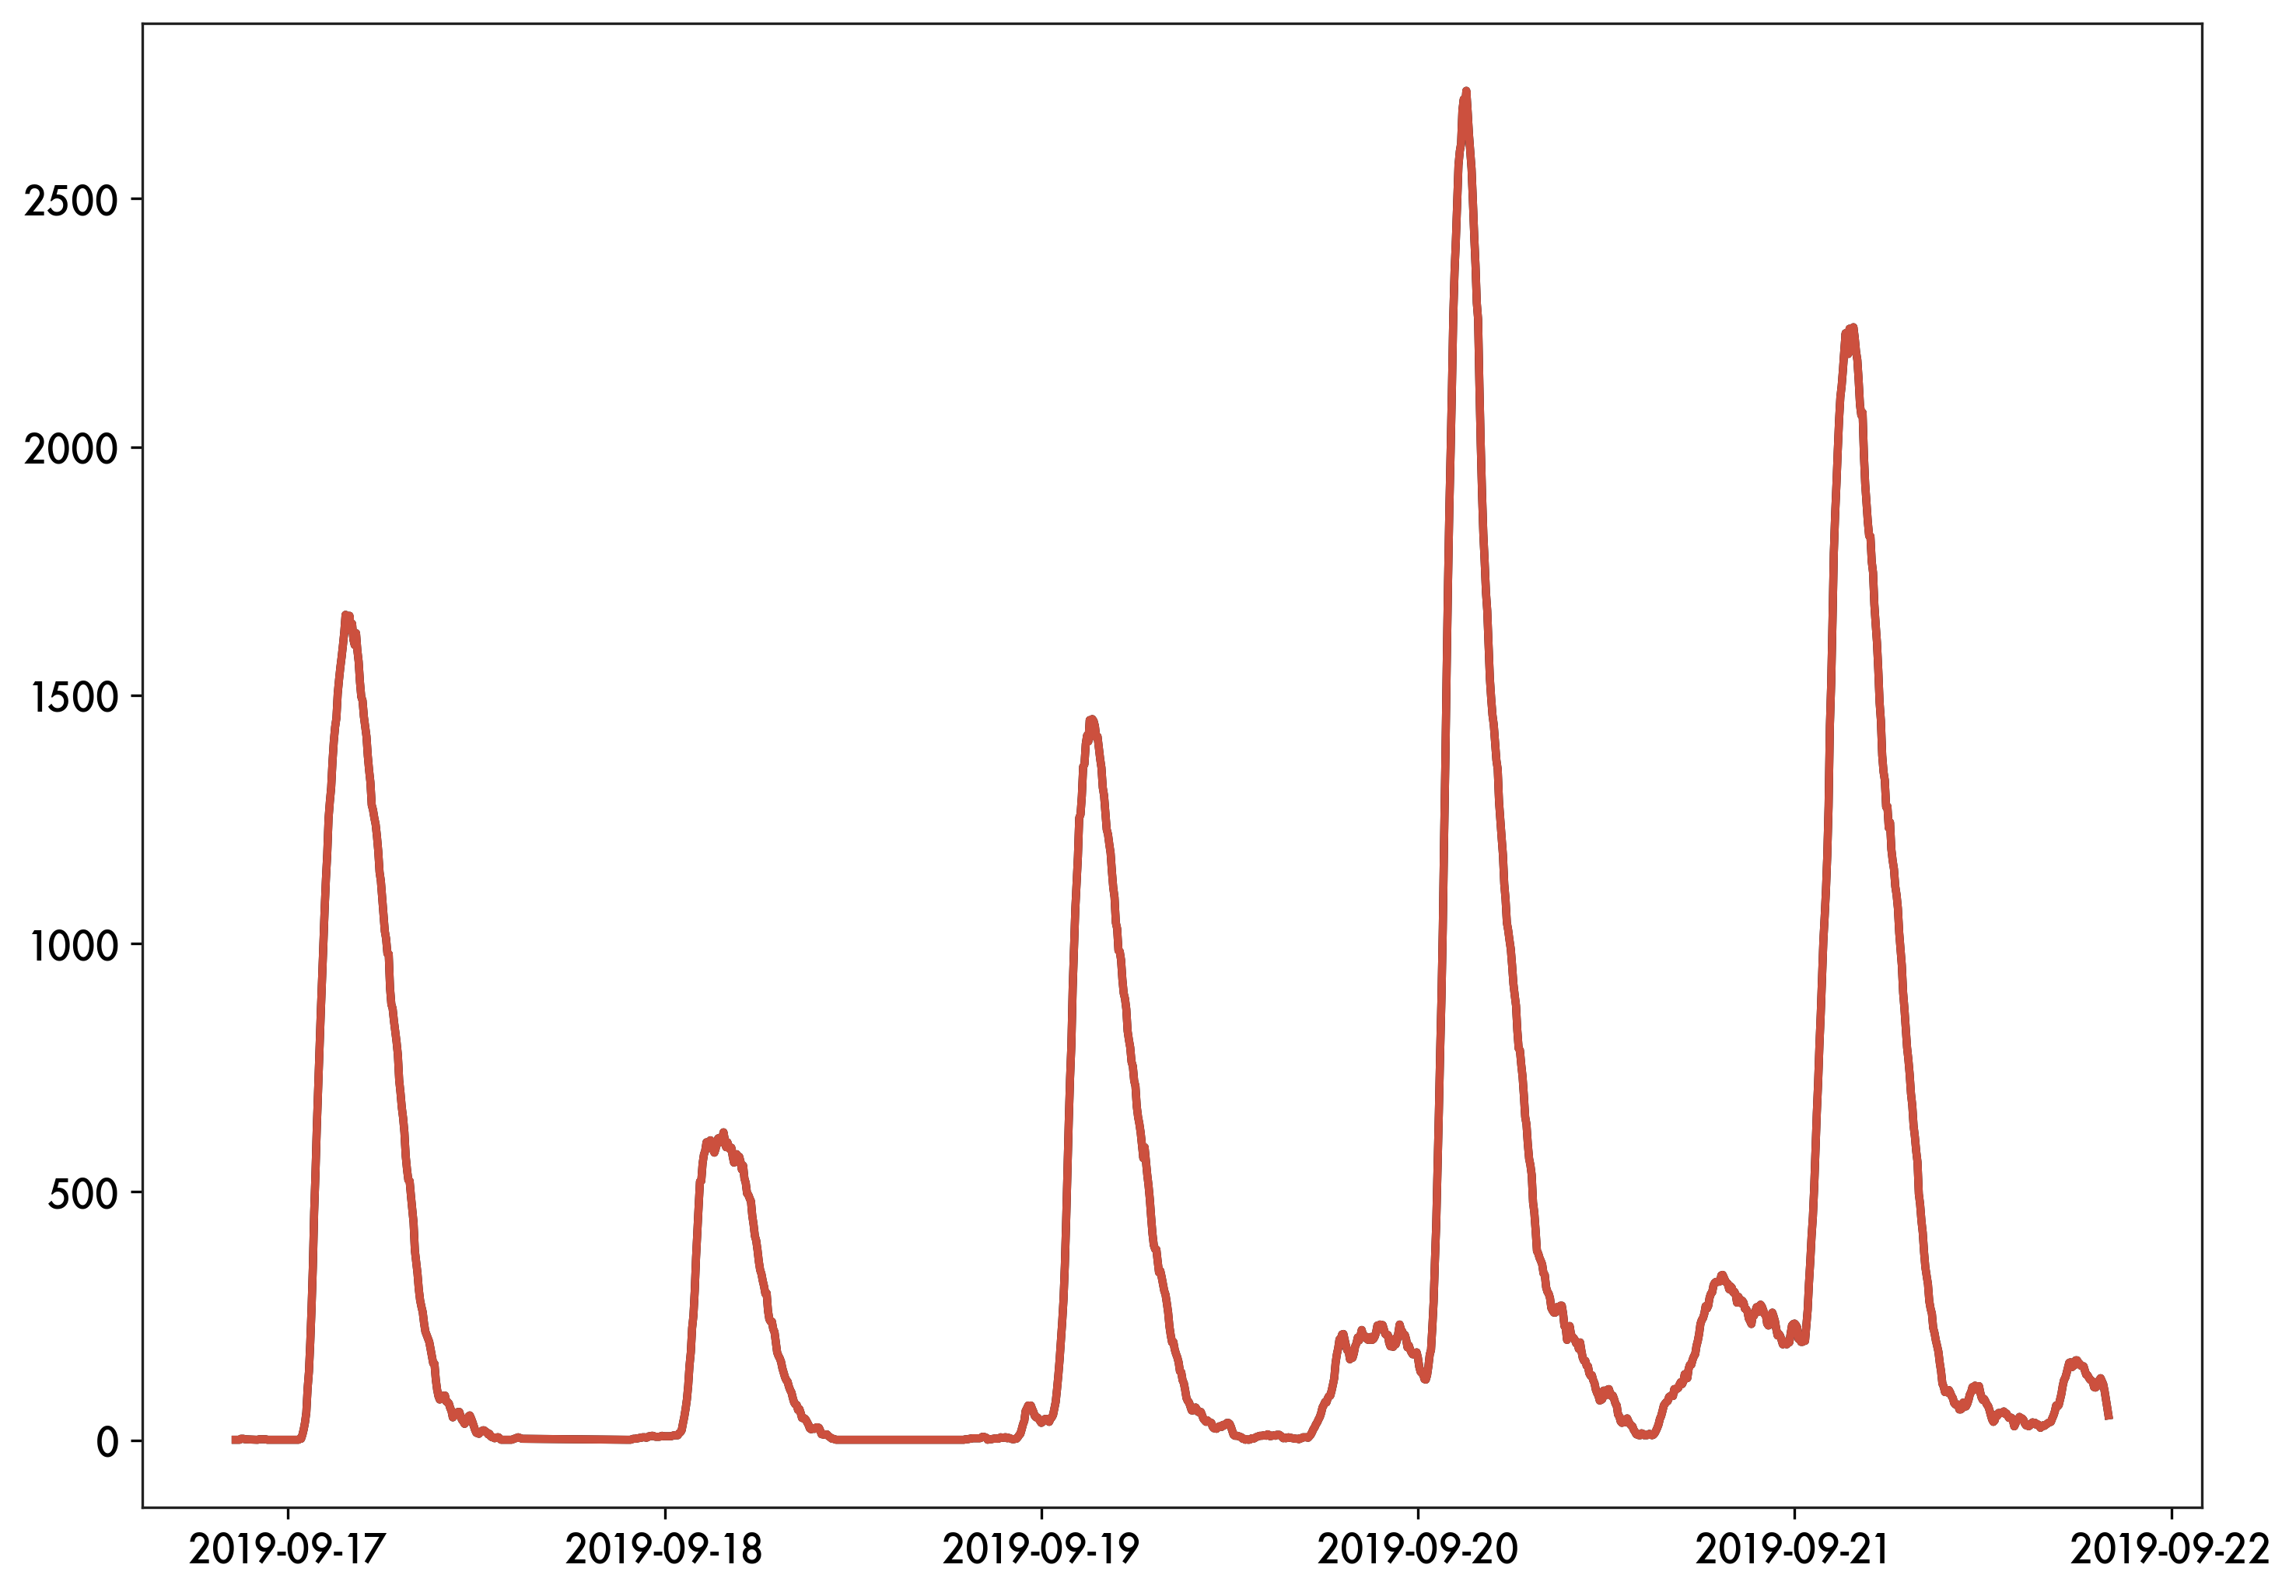

In [122]:
plt.plot(tracks.groupby('time').cell.count(),color='black')
plt.plot(pcp.groupby('time').cell.count(),color=red)

In [123]:
pcp = pcp.set_index(['time','hdim_1','hdim_2','vdim'])

for var in ['pcp_area','pcp_mean','pcp_max','pcp_total']:
    tracks[var] = tracks.index.map(pcp[var])

In [124]:
up = pd.DataFrame()

for i in sorted(glob.glob(f"{tobacPath}/updraft_statistics_*.pq")):
    print(i)
    temp = pd.read_parquet(i)

    if len(up)==0:
        up = temp.copy()
    else:
        new_times = temp.time.unique()
        old_times = up.time.unique()

        if len(np.intersect1d(new_times,old_times))==0:
            up = pd.concat([up, temp]).sort_values('time')
        else:
            up = up[~up.time.isin(np.intersect1d(new_times,old_times))]

            up = pd.concat([up,temp]).sort_values('time')
    # Where the times overlap, should use the more recent one (which I think is only the last pq file made in December vs. the first one made in January)


/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_00.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_01.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_02.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_03.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_04.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_05.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_06.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_07.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_08.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_09.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_10.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_11.pq
/squall/gleung/borneolcc-analysis/tobac/lc2019_rte/updraft_statistics_12.pq
/squall/gleu

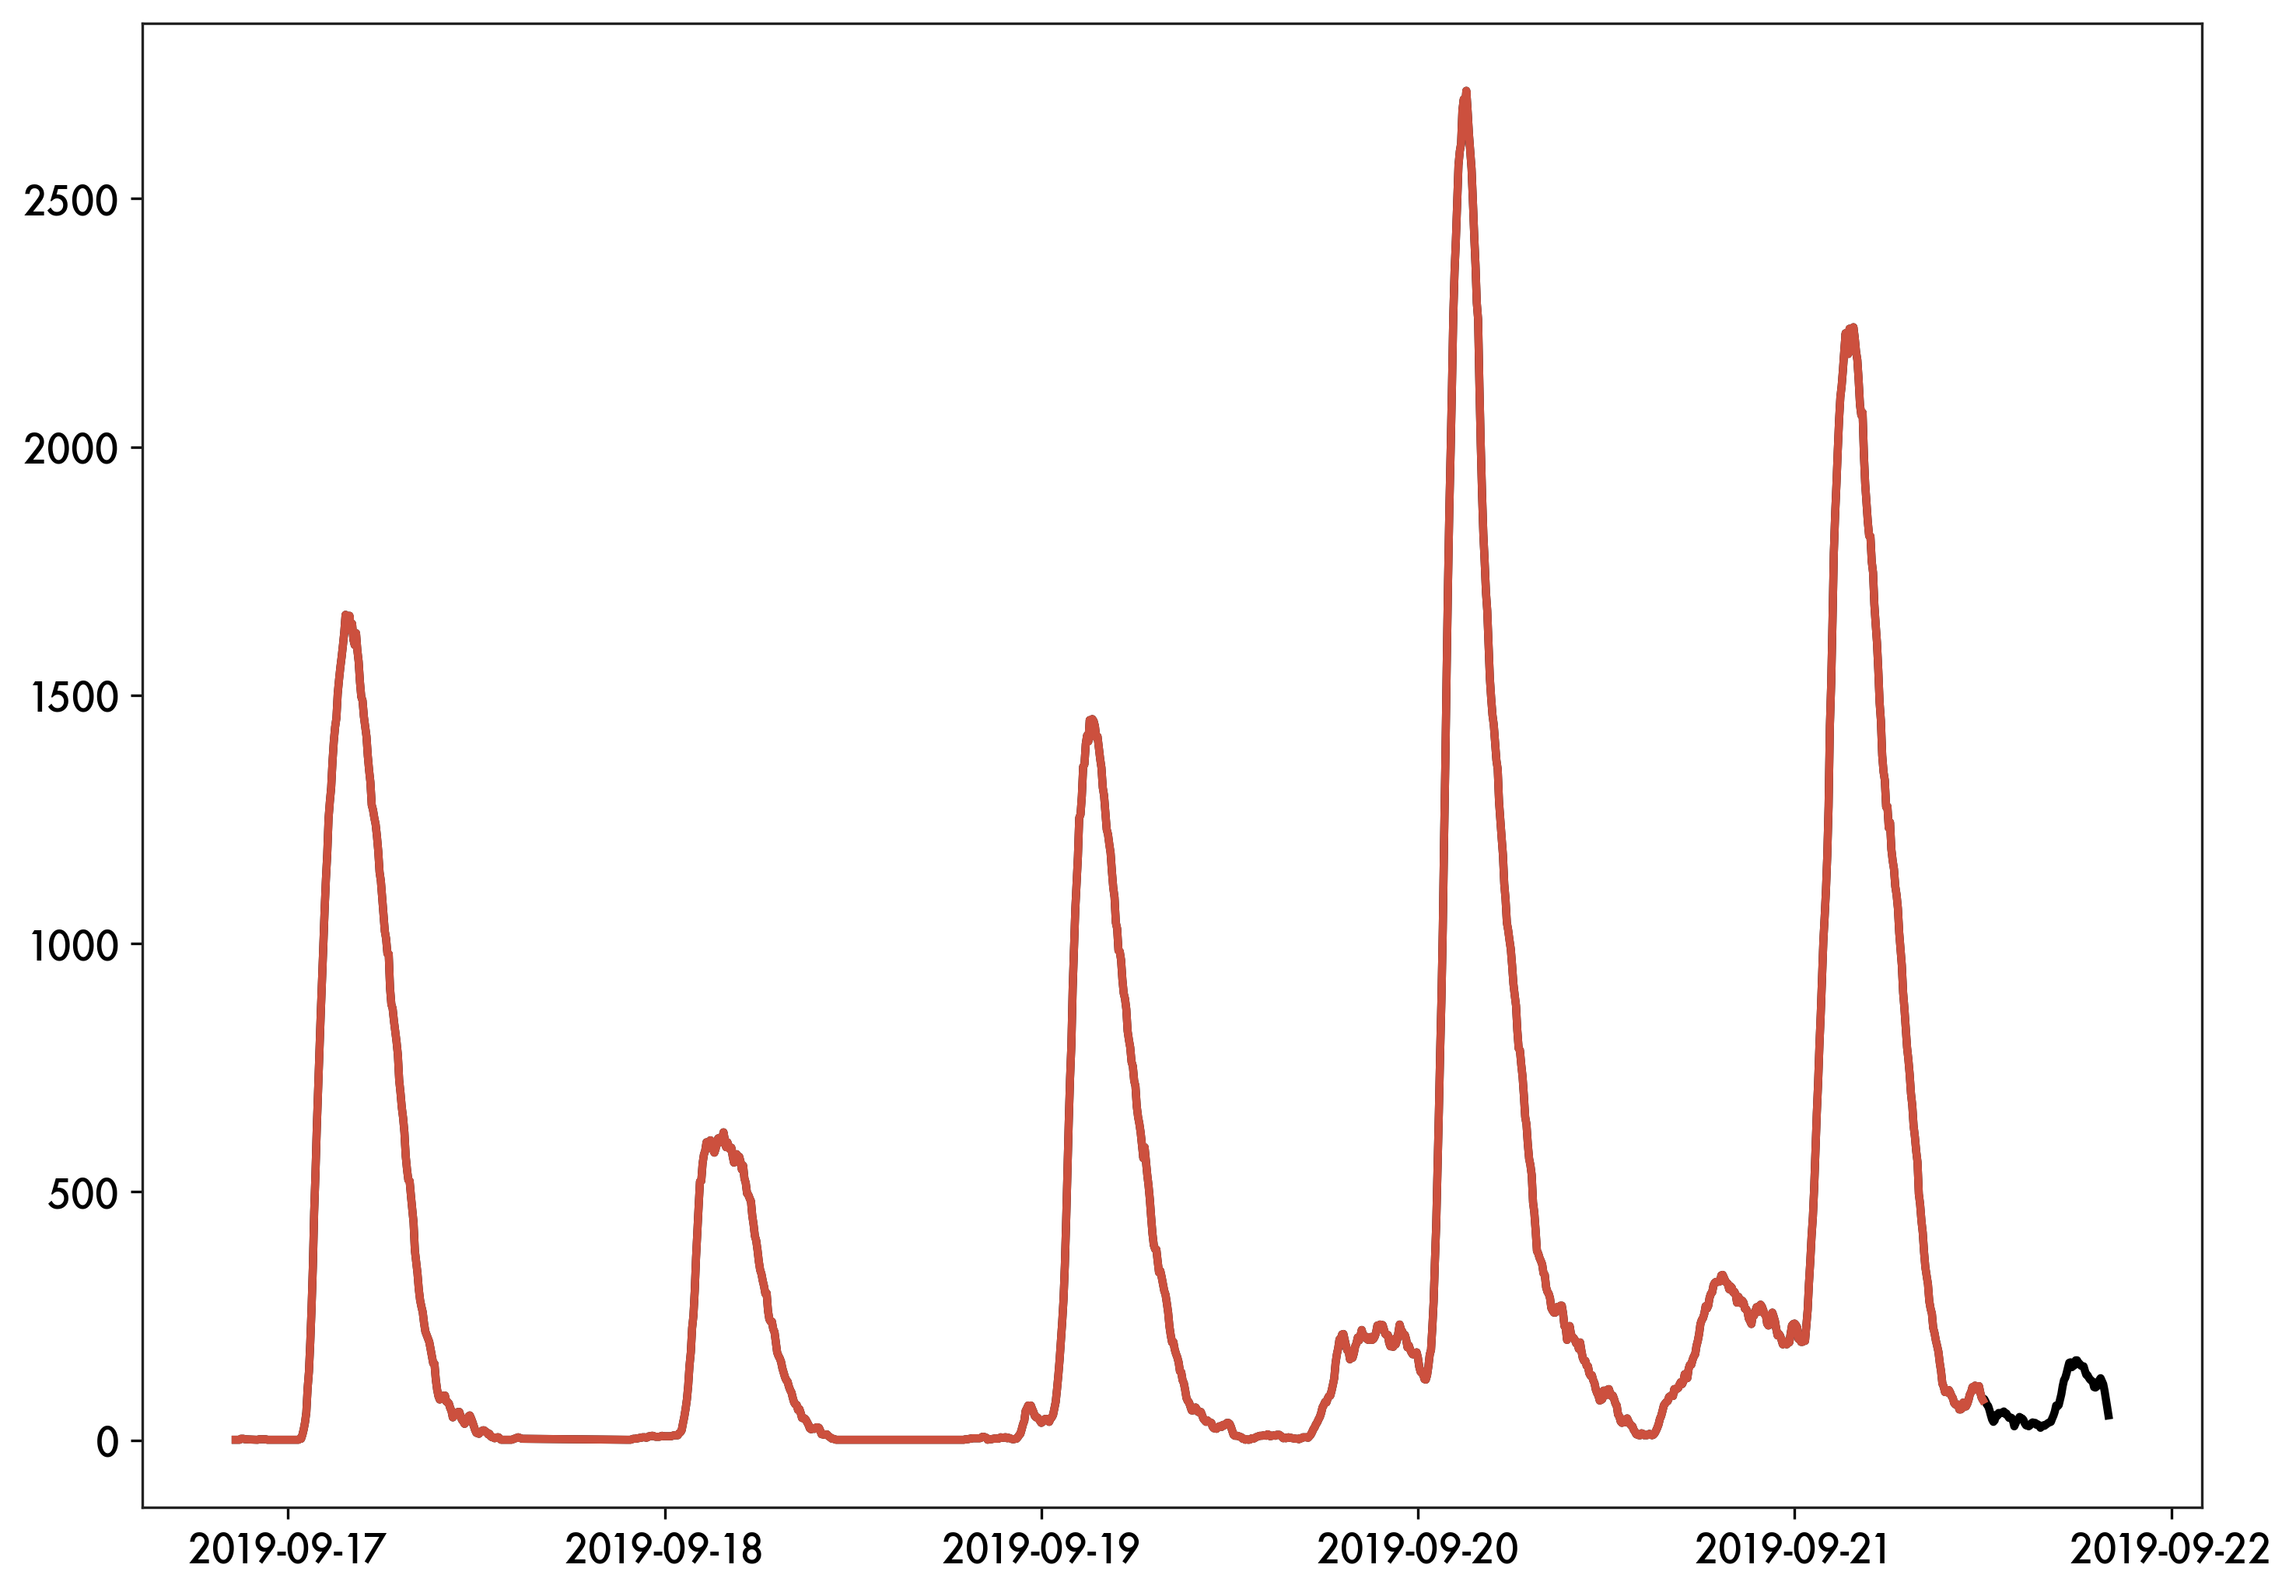

In [125]:
plt.plot(tracks.groupby('time').cell.count(),color='black')
plt.plot(up.groupby('time').cell.count(),color=red)

In [126]:
print(up.columns)

Index(['time', 'cell', 'frame', 'idx', 'vdim', 'hdim_1', 'hdim_2', 'num',
       'threshold_value', 'feature', 'timestr', 'z', 'y', 'x', 'ztn', 'lat',
       'lon', 'time_cell', 'lifetime', 'w_ncells', 'cond_ncells',
       'cellmax_wncells', 'cellmax_condncells', 'local_time', 'updraft_topalt',
       'updraft_botalt', 'updraft_volume', 'updraft_count', 'w_mean', 'w_max',
       'wmax_loc', 'wmax_alt'],
      dtype='object')


In [ ]:
up = up.set_index(['time','hdim_1','hdim_2','vdim'])

for var in ['updraft_topalt','updraft_botalt','updraft_volume','updraft_count','w_mean','w_max','wmax_loc','wmax_alt']:
    tracks[var] = tracks.index.map(up[var])